In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from tensorflow.keras.models import load_model

modelo = load_model("/content/drive/MyDrive/Colab Notebooks/modelos/cnn_aug_bndo_expo.keras")

<IPython.core.display.Javascript object>

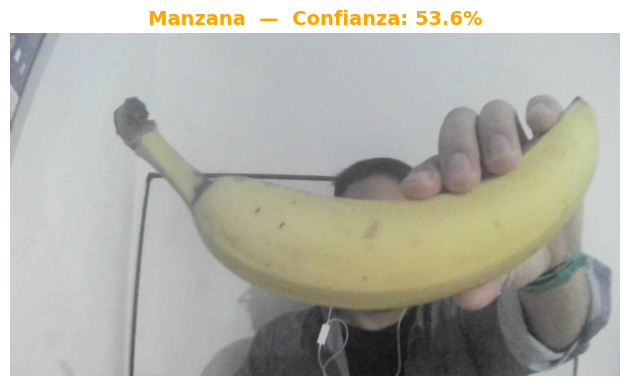

✅ Predicción: Manzana  |  Confianza: 53.6%
   P(naranja): 0.4638  |  P(manzana): 0.5362


In [11]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import cv2
import numpy as np
import PIL.Image
import io
import base64
import matplotlib.pyplot as plt

def take_photo(quality=0.8):
    js = Javascript('''
      async function takePhoto(quality) {
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = '📷 Tomar foto';
        div.appendChild(capture);

        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});

        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();

        await new Promise((resolve) => capture.onclick = resolve);

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getTracks().forEach(track => track.stop());
        div.remove();

        return canvas.toDataURL('image/jpeg', quality);
      }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = io.BytesIO(base64.b64decode(data.split(',')[1]))
    return binary

# Tomar la foto
image_data = take_photo()

IMG_SIZE = (100, 100)

# Leer la imagen con PIL
image = PIL.Image.open(image_data)
image_np = np.array(image)  # → (H, W, 3) en RGB

# Preprocesamiento idéntico al entrenamiento
img_gray  = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
img_gray  = cv2.resize(img_gray, IMG_SIZE)
img_input = img_gray.reshape(1, *IMG_SIZE, 1).astype('float32') / 255.0

# Predicción
prob      = modelo.predict(img_input, verbose=0)[0][0]
if prob >= 0.5:
  clase = "Naranaja"
else:
  clase = "Manzana"
confianza = prob if prob >= 0.5 else 1 - prob

# Mostrar imagen con resultado
plt.imshow(image_np)
plt.axis('off')
plt.title(f'{clase}  —  Confianza: {confianza:.1%}', fontsize=14, fontweight='bold',
          color='green' if confianza > 0.75 else 'orange')
plt.tight_layout()
plt.show()

print(f"✅ Predicción: {clase}  |  Confianza: {confianza:.1%}")
print(f"   P(naranja): {prob:.4f}  |  P(manzana): {1-prob:.4f}")